In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader

from datasets import load_dataset
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)


In [2]:
from torchvision import transforms

# Match what you already did: resize + center crop + normalize for ResNet
embed_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])

class HFStreamImageDataset(IterableDataset):
    """
    Streaming HF dataset -> yields (tensor_image, pil_image, sample_id)
    """
    def __init__(self, hf_name, split="train", image_key="image", max_samples=2000, tfms=None):
        self.ds = load_dataset(hf_name, split=split, streaming=True)
        self.image_key = image_key
        self.max_samples = max_samples
        self.tfms = tfms

    def __iter__(self):
        n = 0
        for ex in self.ds:
            if n >= self.max_samples:
                break
            img = ex[self.image_key]
            if not isinstance(img, Image.Image):
                # some HF datasets store bytes or dicts; handle if needed
                img = Image.fromarray(np.array(img))
            pil_img = img.convert("RGB")
            x = self.tfms(pil_img) if self.tfms else pil_img
            yield x, pil_img, n
            n += 1


In [3]:
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
backbone = nn.Sequential(*list(resnet.children())[:-1]).to(device)  # remove fc, keep avgpool output
backbone.eval()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 39.1MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [6]:
def custom_collate_fn(batch):
    # combine the items yielded by HFStreamImageDataset into a single batch
    tensors = torch.stack([item[0] for item in batch])
    pil_images = [item[1] for item in batch]
    ids = [item[2] for item in batch]
    return tensors, pil_images, ids

def extract_embeddings(hf_name, split="train", max_samples=2000, batch_size=32, num_workers=0):
    ds = HFStreamImageDataset(
        hf_name=hf_name,
        split=split,
        max_samples=max_samples,
        tfms=embed_tfms
    )
    loader = DataLoader(ds, batch_size=batch_size, num_workers=num_workers, collate_fn=custom_collate_fn)

    all_emb = []
    all_imgs = []
    all_ids = []

    with torch.no_grad():
        for xb, pil_imgs, ids in loader:
            xb = xb.to(device)
            feats = backbone(xb)               # (B, 2048, 1, 1)
            feats = feats.squeeze(-1).squeeze(-1)  # (B, 2048)

            all_emb.append(feats.cpu().numpy())
            all_imgs.extend(list(pil_imgs))   # keep PIL images for error analysis
            all_ids.extend(list(ids))

    all_emb = np.vstack(all_emb)
    return {"emb": all_emb, "imgs": all_imgs, "ids": np.array(all_ids)}

In [7]:
MAX_SAMPLES = 2000

data = {}
data["COCO"] = extract_embeddings("HichTala/coco-background", max_samples=MAX_SAMPLES)
data["DIOR"] = extract_embeddings("HichTala/dior-background", max_samples=MAX_SAMPLES)
data["DOTA"] = extract_embeddings("HichTala/dota-background", max_samples=MAX_SAMPLES)

print({k: v["emb"].shape for k, v in data.items()})


Resolving data files:   0%|          | 0/103 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/103 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/275 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/275 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

{'COCO': (2000, 2048), 'DIOR': (2000, 2048), 'DOTA': (2000, 2048)}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


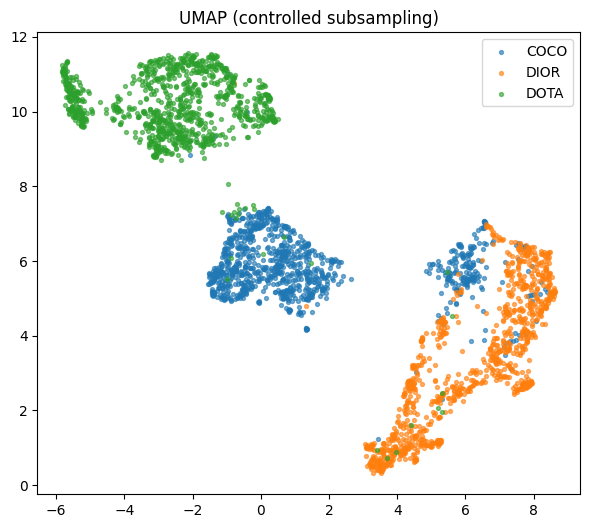

In [8]:
def plot_umap(data_dict, n_per_domain=1000, seed=42):
    import umap

    rng = np.random.default_rng(seed)
    domains = list(data_dict.keys())

    Xs, ys = [], []
    for i, d in enumerate(domains):
        X = data_dict[d]["emb"]
        idx = rng.choice(len(X), size=min(n_per_domain, len(X)), replace=False)
        Xs.append(X[idx])
        ys.append(np.full(len(idx), i))

    X_all = np.vstack(Xs)
    y_all = np.concatenate(ys)

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=seed)
    Z = reducer.fit_transform(X_all)

    plt.figure(figsize=(7,6))
    for i, d in enumerate(domains):
        pts = Z[y_all == i]
        plt.scatter(pts[:,0], pts[:,1], s=8, alpha=0.6, label=d)
    plt.title("UMAP (controlled subsampling)")
    plt.legend()
    plt.show()

plot_umap({"COCO": data["COCO"], "DIOR": data["DIOR"], "DOTA": data["DOTA"]})


In [9]:
def proxy_a_distance_from_accuracy(acc):
    err = 1 - acc
    err = min(err, 1 - err)  # ensure <= 0.5
    return 2 * (1 - 2 * err) # range [0,2]


In [10]:
def show_image_grid(items, title, n=12, cols=4):
    n = min(n, len(items))
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4*cols, 4*rows))
    for i in range(n):
        img, caption = items[i]
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(img)
        ax.set_title(caption, fontsize=10)
        ax.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [11]:
def evaluate_pair(source_name, target_name, data, test_size=0.3, seed=42):
    X_src = data[source_name]["emb"]
    X_tgt = data[target_name]["emb"]

    # Build X, y and keep images for later inspection
    X = np.vstack([X_src, X_tgt])
    y = np.hstack([
        np.zeros(len(X_src), dtype=int),  # 0 = source
        np.ones(len(X_tgt), dtype=int)    # 1 = target
    ])
    imgs = data[source_name]["imgs"] + data[target_name]["imgs"]  # list concatenation

    # Split (stratified) and keep indices for error analysis
    idx = np.arange(len(y))
    idx_train, idx_test, y_train, y_test = train_test_split(
        idx, y, test_size=test_size, random_state=seed, stratify=y
    )
    X_train = X[idx_train]
    X_test  = X[idx_test]

    # Scale (important for Logistic Regression)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Domain classifier
    clf = LogisticRegression(max_iter=2000, n_jobs=-1)
    clf.fit(X_train_s, y_train)

    p_target = clf.predict_proba(X_test_s)[:, 1]      # P(target)
    y_pred = (p_target >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, p_target)
    pad = proxy_a_distance_from_accuracy(acc)

    print("\n" + "="*80)
    print(f"PAIR: {source_name} vs {target_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC (mandatory): {auc:.4f}")
    print(f"Proxy A-distance: {pad:.4f}  (0=similar, 2=max; saturation often means classifier too good)")
    print("-"*80)
    print("Confusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))
    print("-"*80)
    print(classification_report(y_test, y_pred, target_names=[f"{source_name}(source)", f"{target_name}(target)"]))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, p_target)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"ROC — {source_name} vs {target_name} (AUC={auc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # Confidence score analysis (difficulty)
    ambiguous = np.mean((p_target >= 0.45) & (p_target <= 0.55))
    high_conf = np.mean((p_target <= 0.1) | (p_target >= 0.9))

    print("-"*80)
    print("Confidence difficulty:")
    print(f"  Ambiguous (0.45–0.55): {ambiguous*100:.2f}%")
    print(f"  High-confidence (<=0.1 or >=0.9): {high_conf*100:.2f}%")

    # Probability histogram
    plt.figure(figsize=(8,4))
    plt.hist(p_target, bins=50, range=(0,1), edgecolor="black")
    plt.axvline(0.5, linestyle="--")
    plt.title(f"P(target) distribution — {source_name} vs {target_name}")
    plt.xlabel("P(target)")
    plt.ylabel("Count")
    plt.show()

    # ---- Error analysis (image-level) ----
    # Most ambiguous: probabilities closest to 0.5
    amb_order = np.argsort(np.abs(p_target - 0.5))
    amb_samples = []
    for j in amb_order[:12]:
        global_idx = idx_test[j]
        img = imgs[global_idx]
        t = y_test[j]
        pred = y_pred[j]
        prob = p_target[j]
        amb_samples.append((img, f"true={t} pred={pred}\nP(tgt)={prob:.2f}"))

    show_image_grid(amb_samples, title=f"Most ambiguous samples — {source_name} vs {target_name}")

    # Most confidently wrong: wrong predictions with probability far from 0.5
    wrong_mask = (y_pred != y_test)
    if np.any(wrong_mask):
        wrong_idx = np.where(wrong_mask)[0]
        wrong_order = wrong_idx[np.argsort(-np.abs(p_target[wrong_idx] - 0.5))]  # descending confidence
        wrong_samples = []
        for j in wrong_order[:12]:
            global_idx = idx_test[j]
            img = imgs[global_idx]
            t = y_test[j]
            pred = y_pred[j]
            prob = p_target[j]
            wrong_samples.append((img, f"true={t} pred={pred}\nP(tgt)={prob:.2f}"))
        show_image_grid(wrong_samples, title=f"Most confidently wrong — {source_name} vs {target_name}")
    else:
        print("No misclassifications in this split (classifier saturated) — error analysis limited.")

    return {
        "acc": acc, "auc": auc, "pad": pad,
        "ambiguous": ambiguous, "high_conf": high_conf
    }



PAIR: COCO vs DOTA
Accuracy: 0.9958
AUC (mandatory): 1.0000
Proxy A-distance: 1.9833  (0=similar, 2=max; saturation often means classifier too good)
--------------------------------------------------------------------------------
Confusion matrix (rows=true, cols=pred):
[[597   3]
 [  2 598]]
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

COCO(source)       1.00      0.99      1.00       600
DOTA(target)       1.00      1.00      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



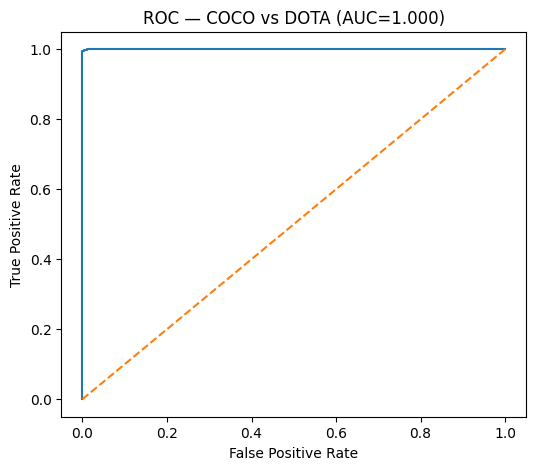

--------------------------------------------------------------------------------
Confidence difficulty:
  Ambiguous (0.45–0.55): 0.08%
  High-confidence (<=0.1 or >=0.9): 98.83%


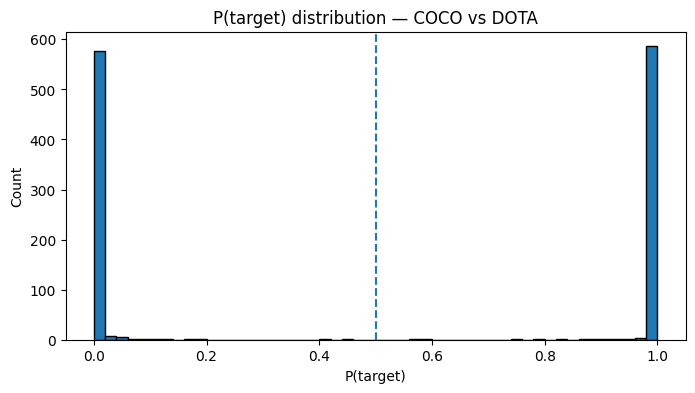

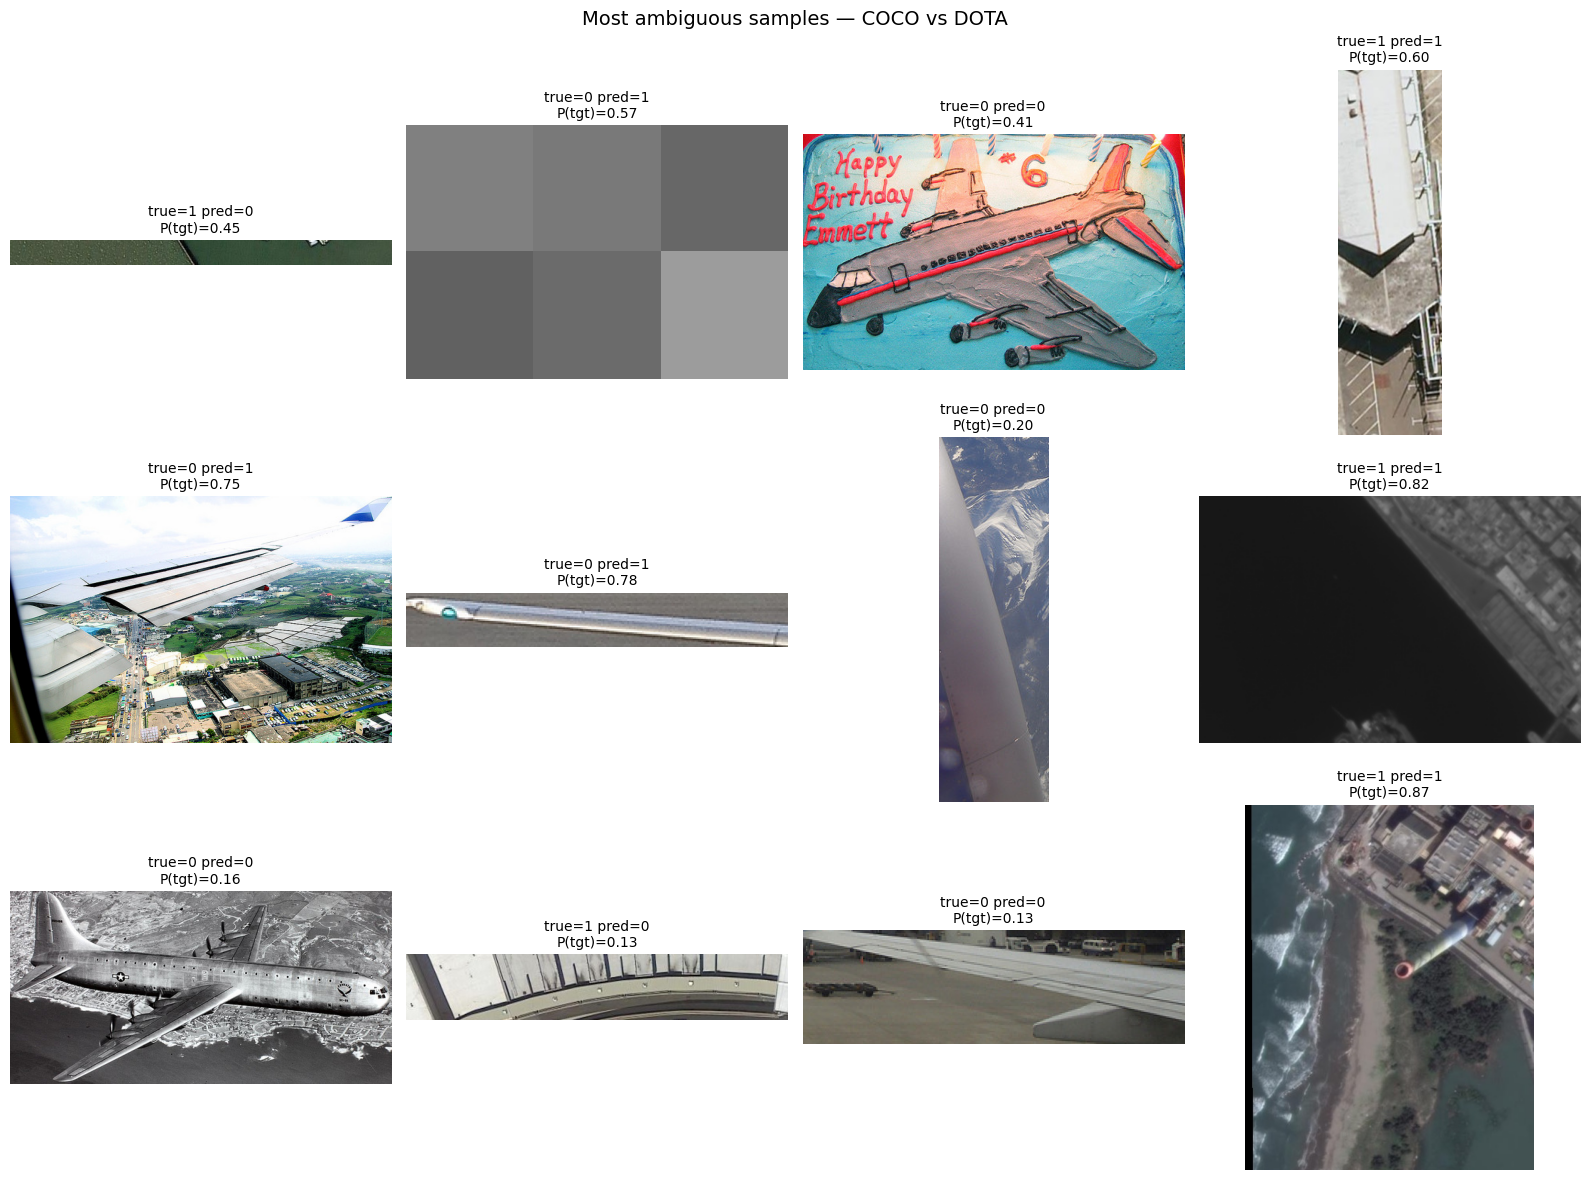

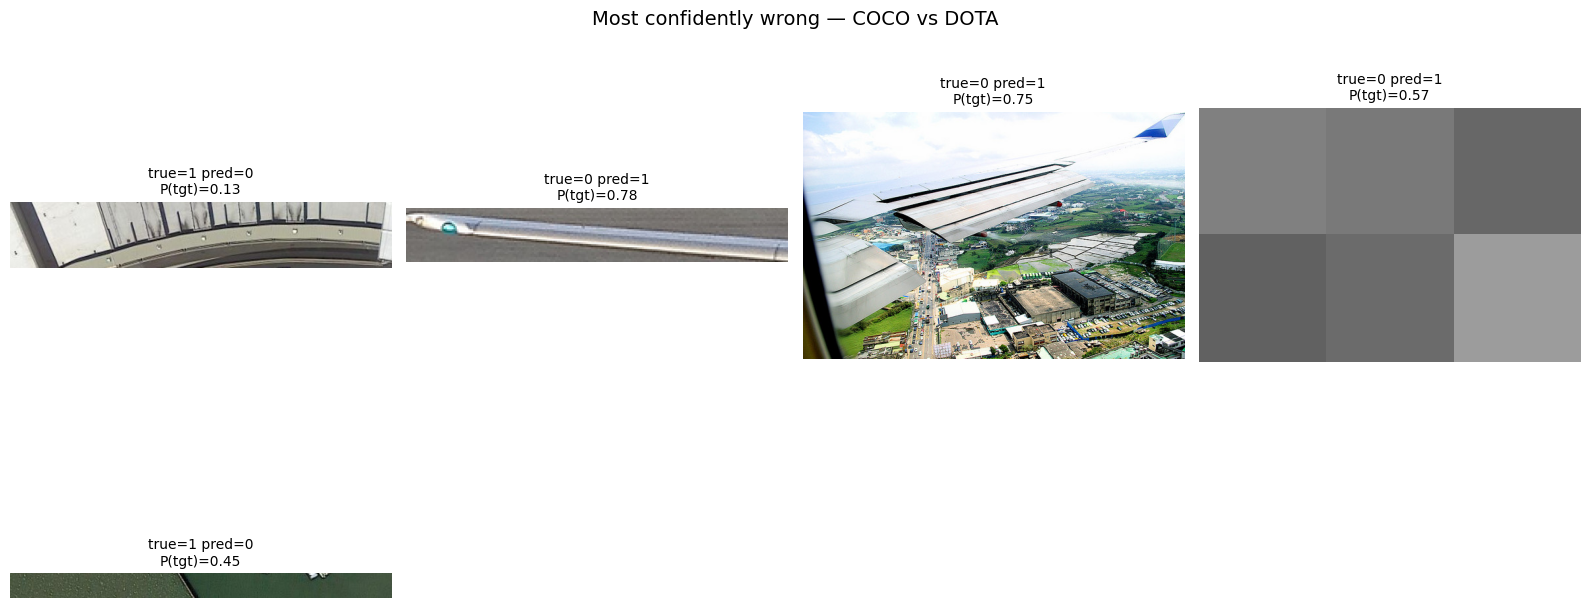


PAIR: DIOR vs DOTA
Accuracy: 0.9983
AUC (mandatory): 1.0000
Proxy A-distance: 1.9933  (0=similar, 2=max; saturation often means classifier too good)
--------------------------------------------------------------------------------
Confusion matrix (rows=true, cols=pred):
[[600   0]
 [  2 598]]
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

DIOR(source)       1.00      1.00      1.00       600
DOTA(target)       1.00      1.00      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



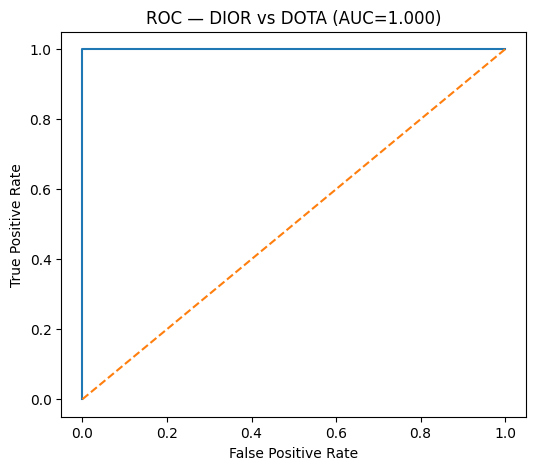

--------------------------------------------------------------------------------
Confidence difficulty:
  Ambiguous (0.45–0.55): 0.00%
  High-confidence (<=0.1 or >=0.9): 99.08%


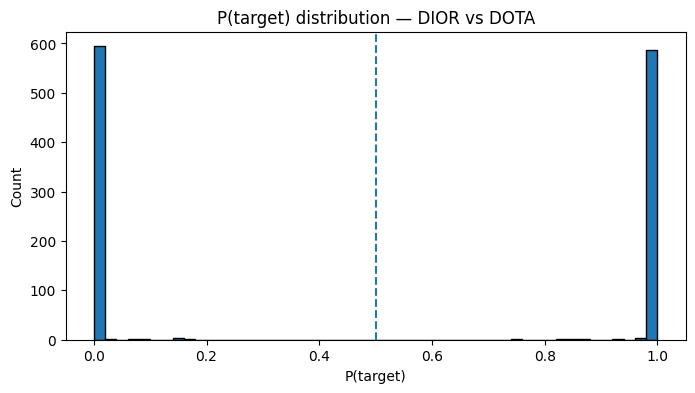

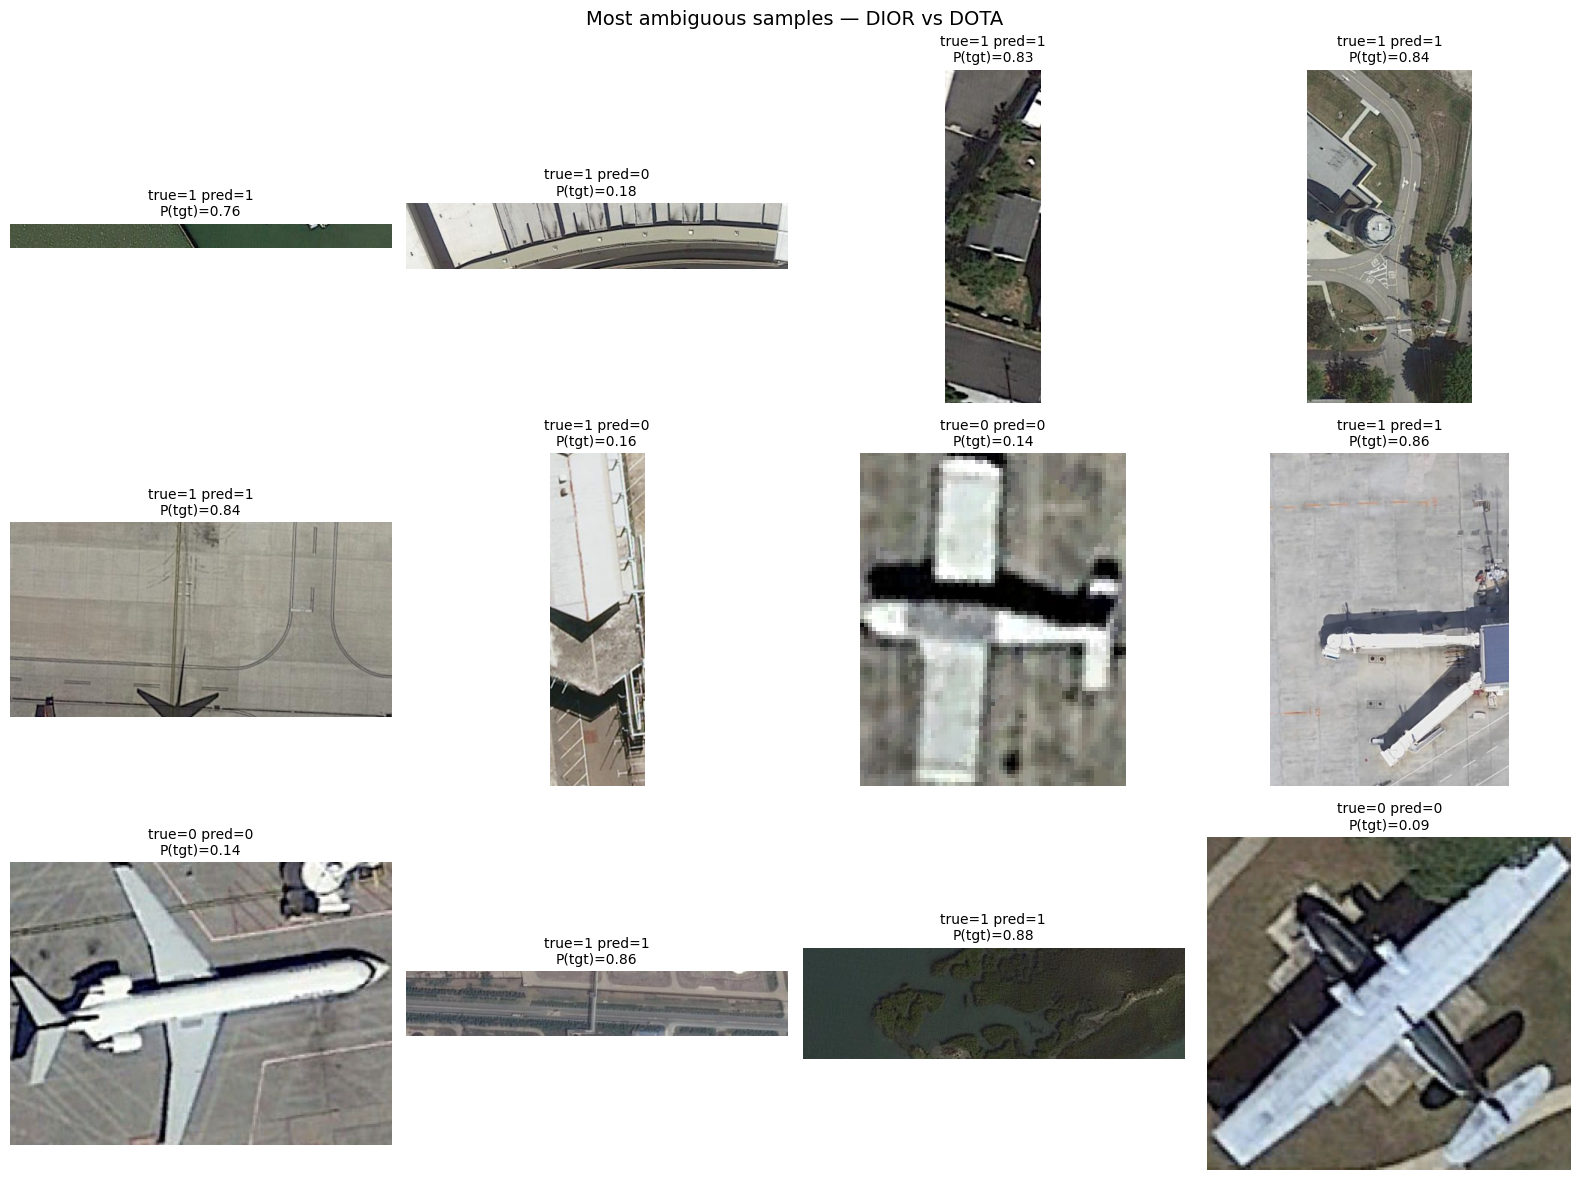

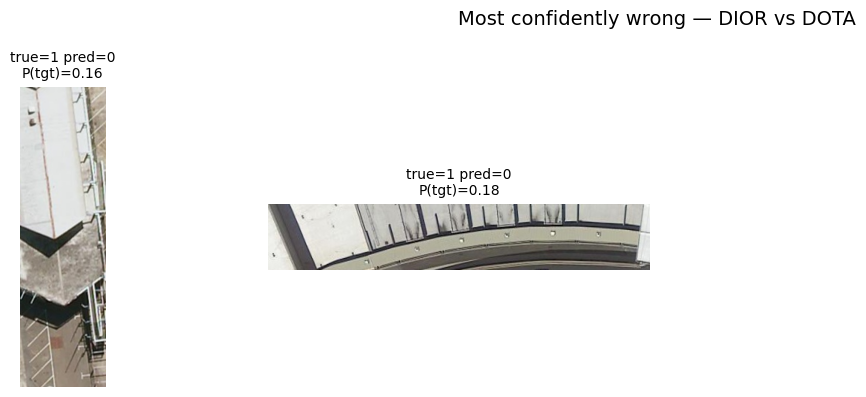


################################################################################
COMPARISON NARRATIVE (fill with your observed numbers)
################################################################################
COCO→DOTA:  AUC=1.000, Ambig%=0.1, PAD=1.983
DIOR→DOTA:  AUC=1.000, Ambig%=0.0, PAD=1.993

Interpretation guide:
- DIOR→DOTA should look 'closer': more ambiguity (more probs near 0.5), lower separability.
- COCO→DOTA should look 'far': high AUC + high-confidence probs near 0/1.
- If PAD is ~2 in both, say it saturates because the classifier is near-perfect; use confidence + UMAP to rank closeness.


In [12]:
metrics_coco_dota = evaluate_pair("COCO", "DOTA", data)
metrics_dior_dota = evaluate_pair("DIOR", "DOTA", data)

print("\n" + "#"*80)
print("COMPARISON NARRATIVE (fill with your observed numbers)")
print("#"*80)
print(f"COCO→DOTA:  AUC={metrics_coco_dota['auc']:.3f}, Ambig%={metrics_coco_dota['ambiguous']*100:.1f}, PAD={metrics_coco_dota['pad']:.3f}")
print(f"DIOR→DOTA:  AUC={metrics_dior_dota['auc']:.3f}, Ambig%={metrics_dior_dota['ambiguous']*100:.1f}, PAD={metrics_dior_dota['pad']:.3f}")



for the confusion matrix Out of 600 COCO samples:

[597 correctly predicted , 3 confused as DOTA]

Out of 600 DOTA samples:

[598 correctly predicted, 2 confused as COCO]

Conclusion: out of all samples in coco vs dota the model predicted 98.80% with high confidence and the ambigouisity with only 0.08% meaning the classifier able to tell the embedding features really well (they are far apart).